# Inference demo — Bangladeshi Taka Detector ✅

This notebook demonstrates a minimal, self-contained inference workflow:

- Loads the trained model (`best.pt`) from the repository (common locations checked)
- Finds sample images (preferably from `Annotated Images from API response` or test sets)
- Runs inference with a confidence threshold
- Saves and visualizes annotated output images in `DISCUSSION AND SCREENSHOTS/inference_demo_outputs`

Run cells sequentially. If a model or image folder is not found, the notebook prints helpful hints.

In [3]:
# 1) Setup: imports and path discovery
from pathlib import Path
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

# ultralytics YOLO model
from ultralytics import YOLO

# Define ROOT as the project root (parent of all phase1, phase2, etc.)
# Try to find it by going up from current working directory
def find_project_root():
    current = Path.cwd()
    # Go up until we find a folder containing "phase1" and "phase2"
    for parent in [current] + list(current.parents):
        if (parent / "phase1").exists() and (parent / "phase2").exists():
            return parent
    return current

ROOT = find_project_root()

# Use explicit paths provided by the user
MODEL_PATH = ROOT / "phase2" / "model_weights" / "best.pt"
if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Model not found at {MODEL_PATH}. Tried: {MODEL_PATH}")

# Use test images from filtered dataset
IMAGE_DIR = ROOT / "phase1" / "dataset" / "filtered" / "test" / "images"
if not IMAGE_DIR.exists():
    raise FileNotFoundError(f"Image directory not found at {IMAGE_DIR}. Tried: {IMAGE_DIR}")

print(f"✅ Project root: {ROOT}")
print(f"✅ Model path: {MODEL_PATH}")
print(f"✅ Image directory: {IMAGE_DIR}")

✅ Project root: d:\Study\Ostad\11. Model Finetuning & Intro to Transformers\Assignment\Bangladesh_Currency_Detection_YOLO
✅ Model path: d:\Study\Ostad\11. Model Finetuning & Intro to Transformers\Assignment\Bangladesh_Currency_Detection_YOLO\phase2\model_weights\best.pt
✅ Image directory: d:\Study\Ostad\11. Model Finetuning & Intro to Transformers\Assignment\Bangladesh_Currency_Detection_YOLO\phase1\dataset\filtered\test\images


In [4]:
# 2) Load the YOLO model
# If the model file doesn't exist, the cell will still try to create a YOLO object so the user sees the error clearly.
print("Loading model...")
model = YOLO(str(MODEL_PATH))
print(model.info())

Loading model...
YOLOv12m summary: 292 layers, 20,144,427 parameters, 0 gradients, 67.8 GFLOPs
(292, 20144427, 0, 67.7739008)


In [5]:
# 3) Collect sample images
images = [p for p in IMAGE_DIR.iterdir() if p.suffix.lower() in ('.png', '.jpg', '.jpeg')]
if not images:
    raise FileNotFoundError(f"No images found in {IMAGE_DIR}. Please add images to the folder or update IMAGE_DIR_CANDIDATES.")

sample_images = random.sample(images, min(6, len(images)))
print("Sample images:")
for p in sample_images:
    print(" -", p.name)

Sample images:
 - 1000_128_jpg.rf.11bae4e4ed3b971175557a8a0bed8d6c.jpg
 - 10_65_jpg.rf.aec9b8c88e80e92cd99cc2c87b5fca9f.jpg
 - 2_67_jpg.rf.fe565e1eabd2b6145e130112b86f6081.jpg
 - 50_51_jpg.rf.2fa3d3c473c05d46b2dff86b98300bd7.jpg
 - 100_39_jpg.rf.2f6839709bcf5298c13994bd90db30bd.jpg
 - 2_83_jpg.rf.a261893ee23b06f1fc0f5196fb7de5ab.jpg



Running inference on: 1000_128_jpg.rf.11bae4e4ed3b971175557a8a0bed8d6c.jpg


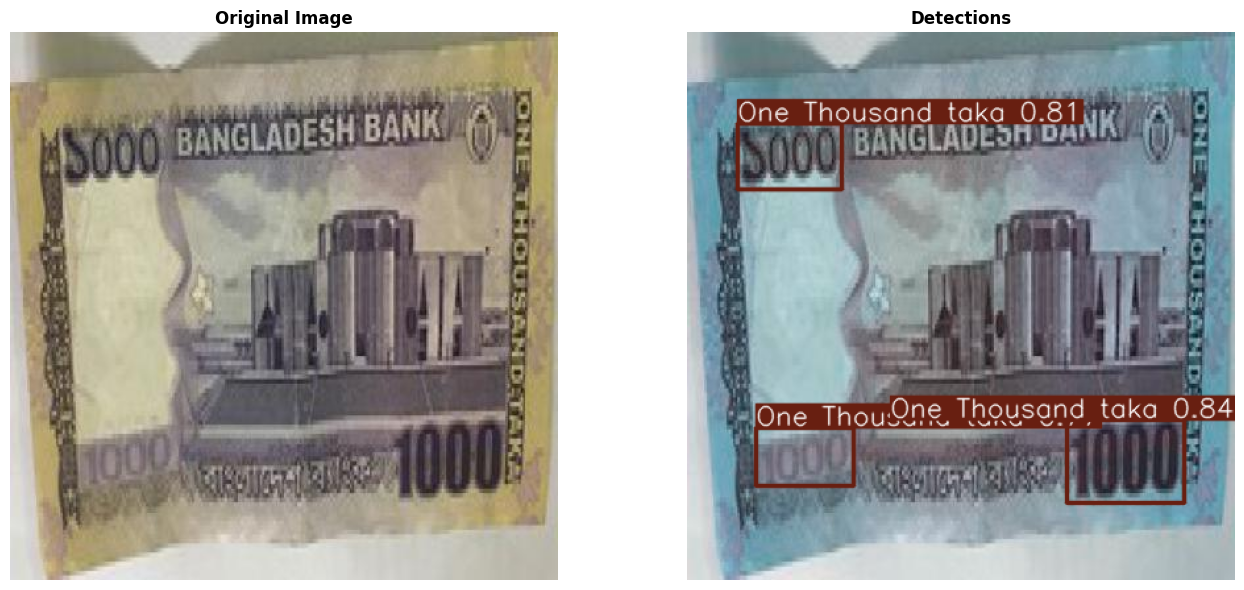


✓ Found 3 detection(s):
  1. class_id=4, confidence=83.96%, bbox=[288.4, 294.9, 377.4, 358.0]
  2. class_id=4, confidence=80.85%, bbox=[38.6, 69.3, 117.1, 119.2]
  3. class_id=4, confidence=76.72%, bbox=[52.4, 300.8, 126.1, 344.4]

Running inference on: 10_65_jpg.rf.aec9b8c88e80e92cd99cc2c87b5fca9f.jpg


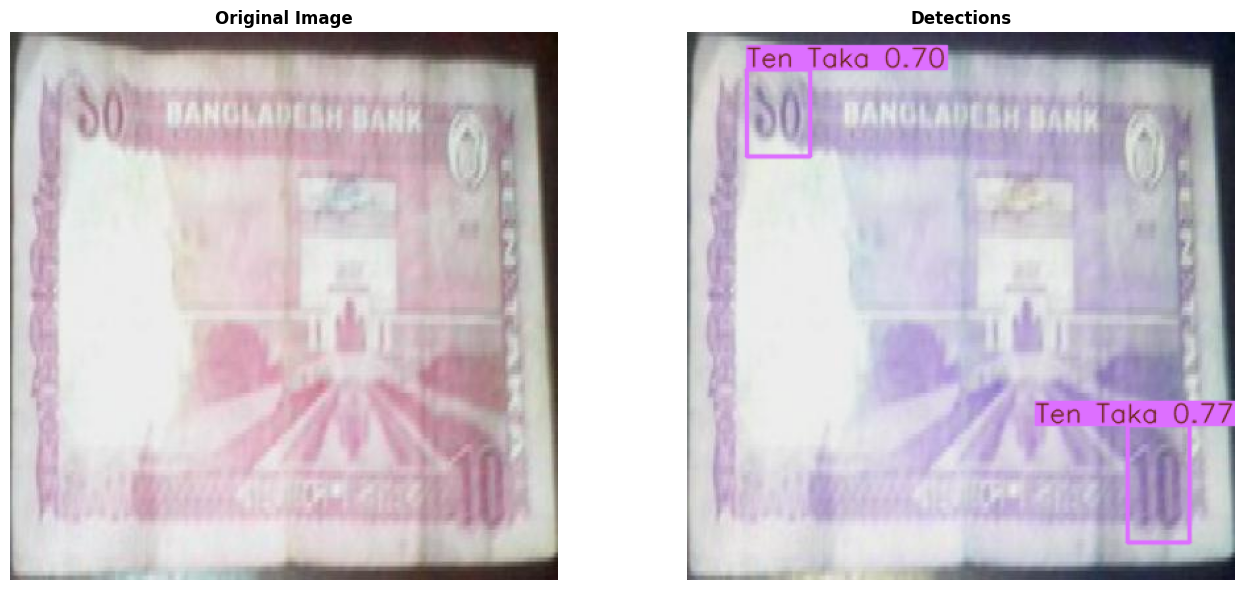


✓ Found 2 detection(s):
  1. class_id=5, confidence=76.71%, bbox=[334.4, 298.9, 381.2, 387.1]
  2. class_id=5, confidence=69.61%, bbox=[45.1, 28.9, 93.3, 94.8]

Running inference on: 2_67_jpg.rf.fe565e1eabd2b6145e130112b86f6081.jpg


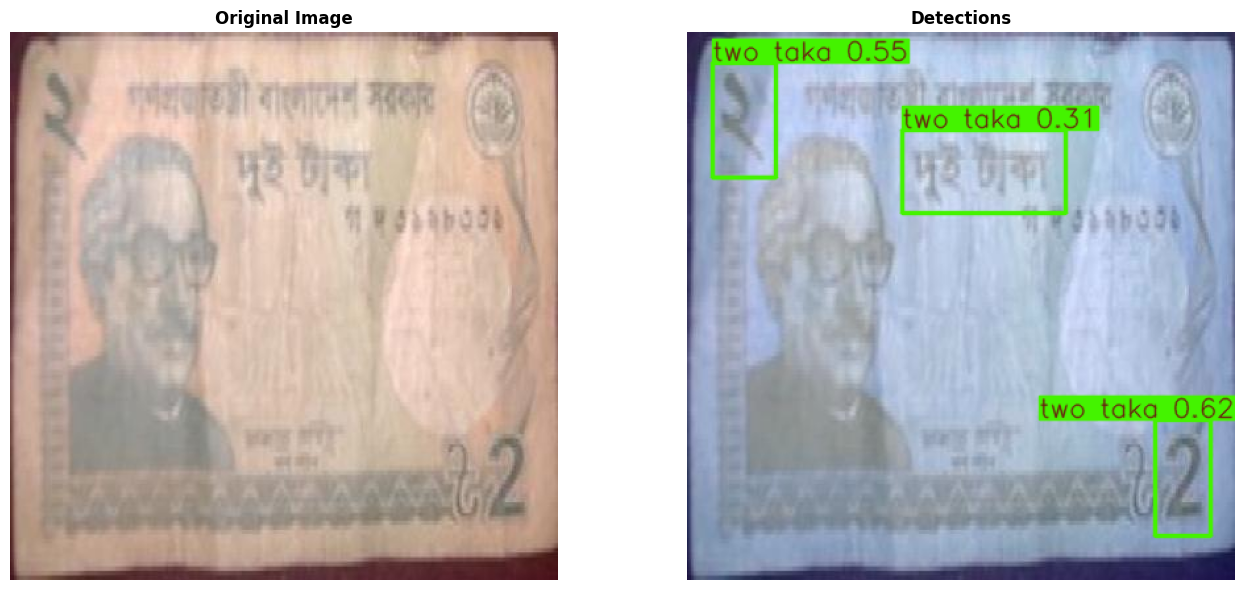


✓ Found 3 detection(s):
  1. class_id=8, confidence=61.64%, bbox=[355.6, 294.6, 397.9, 382.7]
  2. class_id=8, confidence=55.14%, bbox=[20.0, 23.1, 67.3, 110.7]
  3. class_id=8, confidence=31.21%, bbox=[163.9, 75.0, 287.5, 137.9]

Running inference on: 50_51_jpg.rf.2fa3d3c473c05d46b2dff86b98300bd7.jpg


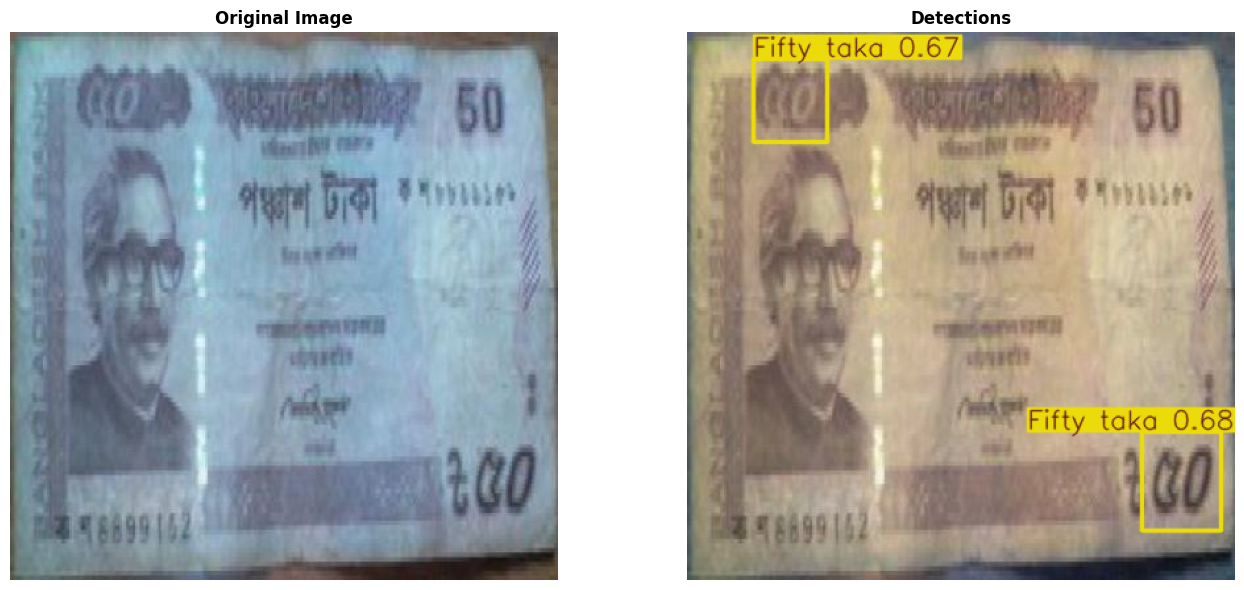


✓ Found 2 detection(s):
  1. class_id=1, confidence=68.47%, bbox=[345.8, 303.5, 405.3, 378.4]
  2. class_id=1, confidence=67.09%, bbox=[50.4, 20.6, 106.3, 84.0]

Running inference on: 100_39_jpg.rf.2f6839709bcf5298c13994bd90db30bd.jpg


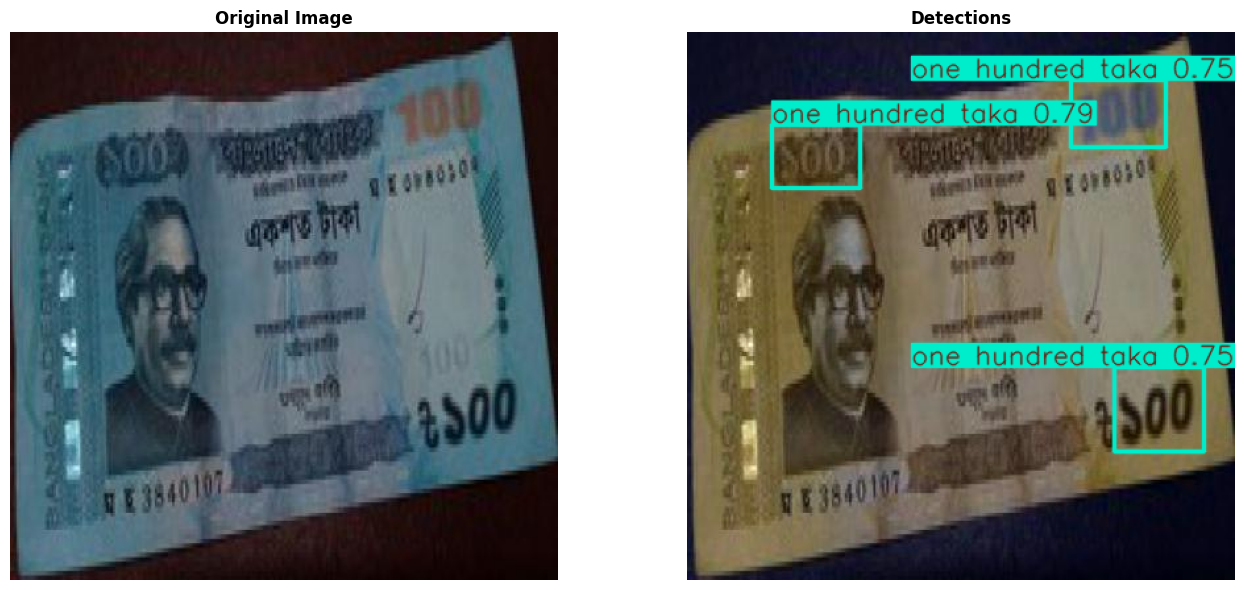


✓ Found 3 detection(s):
  1. class_id=7, confidence=78.82%, bbox=[64.4, 70.8, 131.6, 118.2]
  2. class_id=7, confidence=75.37%, bbox=[291.0, 36.8, 363.0, 87.5]
  3. class_id=7, confidence=74.67%, bbox=[324.9, 254.7, 392.1, 318.6]

Running inference on: 2_83_jpg.rf.a261893ee23b06f1fc0f5196fb7de5ab.jpg


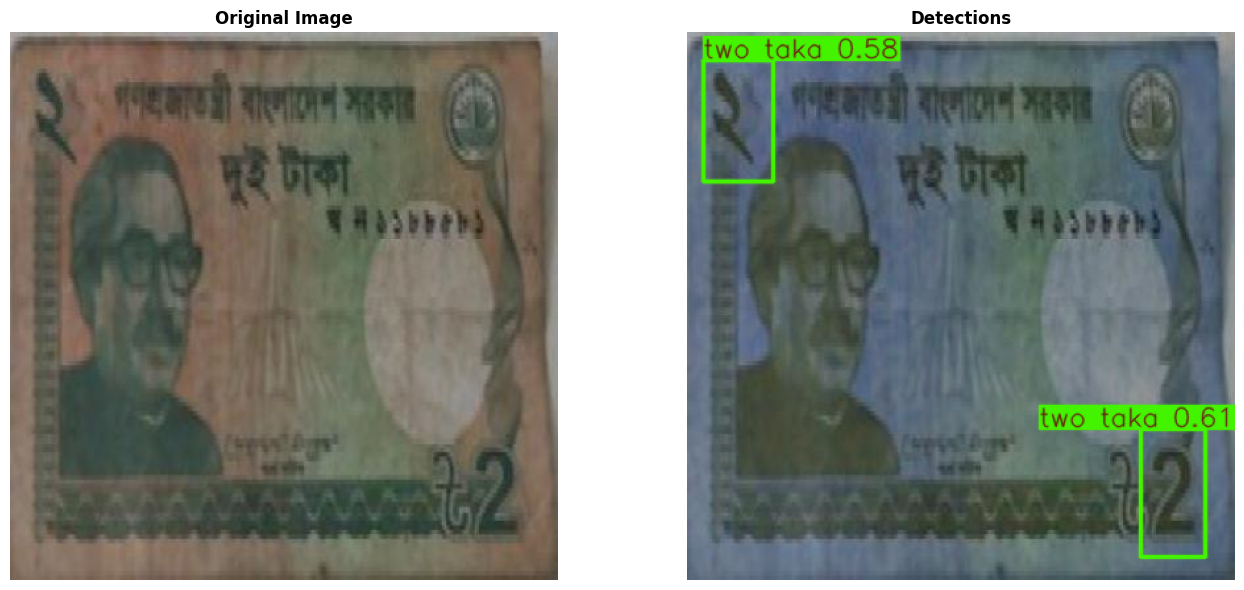


✓ Found 2 detection(s):
  1. class_id=8, confidence=60.66%, bbox=[344.9, 301.5, 393.5, 398.5]
  2. class_id=8, confidence=58.13%, bbox=[12.2, 22.0, 65.9, 113.2]

✅ Inference demo complete!


In [6]:
# 4) Run inference and display results (no file saving)
CONF_THRESH = 0.25

for img_path in sample_images:
    print('\n' + '='*60)
    print(f'Running inference on: {img_path.name}')
    print('='*60)

    # Run prediction (returns Results object)
    results = model.predict(source=str(img_path), conf=CONF_THRESH, verbose=False)
    res = results[0]

    # Load original image and display with detections
    original_img = Image.open(img_path)
    annotated = res.plot()  # returns HxWx3 numpy array
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Original image
    ax1.imshow(original_img)
    ax1.set_title('Original Image', fontsize=12, fontweight='bold')
    ax1.axis('off')
    
    # Annotated image with detections
    ax2.imshow(annotated)
    ax2.set_title('Detections', fontsize=12, fontweight='bold')
    ax2.axis('off')
    
    plt.tight_layout()
    plt.show()

    # Print detection details
    if len(res.boxes) > 0:
        print(f'\n✓ Found {len(res.boxes)} detection(s):')
        for i, box in enumerate(res.boxes):
            cls_id = int(box.cls[0])
            conf = float(box.conf[0])
            coords = box.xyxy[0].cpu().numpy().tolist()
            print(f"  {i+1}. class_id={cls_id}, confidence={conf:.2%}, bbox={[round(c, 1) for c in coords]}")
    else:
        print('ℹ No detections above threshold.')

print('\n' + '='*60)
print('✅ Inference demo complete!')
print('='*60)

## Summary

✅ **What this notebook does:**
- Automatically detects the project root by looking for `phase1` and `phase2` folders
- Loads the trained model from `phase2/model_weights/best.pt`
- Selects 6 random test images from `phase1/dataset/filtered/test/images`
- Runs inference on each image at 0.25 confidence threshold
- Displays side-by-side comparisons (original vs. annotated with bounding boxes)
- Prints detection details (class ID, confidence, bounding box coordinates)

**All outputs are displayed inline in the notebook — no files are saved.**